# XGBoost Peak Hour Classification with Weather

**Approach:**
- 24-class classification (direct peak hour prediction)
- Target: each day's peak hour (0-23)
- Features: dailty aggregate features
- Integrate Weather variables

**Hyperparameter Tuning:**
- Time-based CV (2020-2024)
- Area-specific best parameters

In [1]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 1: Load and Merge Data

Load engineered features and merge with weather data

In [2]:
!python ./fetch_weather_historical.py

FETCHING HISTORICAL WEATHER DATA (2016-2024)

Fetching weather data for: 2016-01-01 to 2024-12-31
Location: Philadelphia (39.95, -75.16)

Requesting 5 weather variables...
  • temperature_2m
  • apparent_temperature
  • relative_humidity_2m
  • shortwave_radiation
  • wind_speed_10m

Making API request... (this may take a minute)
✓ API response received
  Rows: 78,912
  Date range: 2016-01-01 00:00:00 to 2024-12-31 23:00:00

Adding derived features...
  Added 7 derived features
  Final columns: 13

✓ Saved: ../dataset/preprocessed/weather_data_historical.parquet
  Size: 2.14 MB
✓ Saved: ../dataset/preprocessed/weather_data_historical.csv
  Size: 7.77 MB

SUMMARY
Total records: 78,912
Total features: 13
Date range: 2016-01-01 00:00:00 to 2024-12-31 23:00:00

✓ No missing values

✓ HISTORICAL WEATHER DATA FETCH COMPLETED


## Step 2: Define Features

Two feature sets:
1. **Base features**: Time + historical power features
2. **Weather features**: All weather variables

## Configuration

In [6]:
# Evaluation years
EVAL_YEARS = list(range(2016, 2025))

# Year-based CV windows
CV_WINDOWS = [
    {'train_years': [2016, 2017, 2018, 2019], 'test_year': 2020},
    {'train_years': [2017, 2018, 2019, 2020], 'test_year': 2021},
    {'train_years': [2018, 2019, 2020, 2021], 'test_year': 2022},
    {'train_years': [2019, 2020, 2021, 2022], 'test_year': 2023},
    {'train_years': [2020, 2021, 2022, 2023], 'test_year': 2024}
]

# Black Friday helper
def get_black_friday(year):
    """Returns the Black Friday date for a given year"""
    nov_first = datetime(year, 11, 1)
    days_until_thursday = (3 - nov_first.weekday()) % 7
    first_thursday = nov_first + timedelta(days=days_until_thursday)
    thanksgiving = first_thursday + timedelta(weeks=3)
    black_friday = thanksgiving + timedelta(days=1)
    return black_friday

print(f"Evaluation years: {EVAL_YEARS}")
print(f"CV windows: {len(CV_WINDOWS)}")

Evaluation years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
CV windows: 5


## Load Data

In [7]:
# Load historical data
print("Loading data...")
df = pd.read_parquet('../dataset/preprocessed/full_year_features.parquet')
df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'])

print(f"Data loaded: {len(df):,} rows")
print(f"Date range: {df['datetime_beginning_ept'].min()} to {df['datetime_beginning_ept'].max()}")
print(f"Load areas: {df['load_area'].nunique()}")

Loading data...
Data loaded: 3,367,288 rows
Date range: 2012-01-01 00:00:00 to 2025-11-13 23:00:00
Load areas: 34


## Feature Engineering: Daily-Level Features

In [19]:
def create_daily_features(df):
    """Create daily-level features for peak hour classification"""
    print("Creating daily-level features...")
    
    df['date'] = df['datetime_beginning_ept'].dt.date
    
    # Get peak hour for each date/area
    daily_peaks = df.groupby(['date', 'load_area']).agg({
        'mw': 'idxmax'
    }).reset_index()
    
    daily_peaks['peak_hour'] = daily_peaks['mw'].map(
        lambda idx: df.loc[idx, 'hour'] if pd.notna(idx) else np.nan
    )
    
    daily_peaks['datetime_beginning_ept'] = df['datetime_beginning_ept']
    daily_peaks['datetime'] = pd.to_datetime(daily_peaks['date'])
    daily_peaks = daily_peaks.drop('mw', axis=1)
    
    print(f"  Created {len(daily_peaks):,} daily records")
    
    # Add temporal features
    daily_peaks['day_of_week'] = daily_peaks['datetime'].dt.dayofweek
    daily_peaks['month'] = daily_peaks['datetime'].dt.month
    daily_peaks['day_of_month'] = daily_peaks['datetime'].dt.day
    daily_peaks['year'] = daily_peaks['datetime'].dt.year
    daily_peaks['is_blackfriday'] = 0
    daily_peaks['is_thanksgiving'] = 0
    daily_peaks['days_from_bf'] = 0
    
    for year in daily_peaks['year'].unique():
        bf_date = get_black_friday(year)
        thanksgiving_date = bf_date - timedelta(days=1)
        
        mask = daily_peaks['year'] == year
        daily_peaks.loc[mask, 'is_blackfriday'] = (
            daily_peaks.loc[mask, 'datetime'].dt.date == bf_date.date()
        ).astype(int)
        daily_peaks.loc[mask, 'is_thanksgiving'] = (
            daily_peaks.loc[mask, 'datetime'].dt.date == thanksgiving_date.date()
        ).astype(int)
        daily_peaks.loc[mask, 'days_from_bf'] = (
            daily_peaks.loc[mask, 'datetime'].dt.date - bf_date.date()
        ).apply(lambda x: x.days)
    
    print("  Added temporal features")
    
    # Create lag features
    lag_days = [2, 3, 4, 5, 6, 7, 8, 9, 365, 730, 1095, 1460]
    
    for lag in lag_days:
        print(f"  Creating lag_{lag}d feature...")
        daily_peaks[f'peak_hour_lag_{lag}d'] = np.nan
        
        for area in daily_peaks['load_area'].unique():
            area_mask = daily_peaks['load_area'] == area
            area_data = daily_peaks[area_mask].set_index('datetime').sort_index()
            lagged = area_data['peak_hour'].shift(freq=f'{lag}D')
            daily_peaks.loc[area_mask, f'peak_hour_lag_{lag}d'] = (
                daily_peaks.loc[area_mask, 'datetime'].map(lagged.to_dict())
            )
    
    print("✓ Daily features created")
    return daily_peaks

daily_df = create_daily_features(df)

print(f"\nFinal dataset: {len(daily_df):,} rows")

Creating daily-level features...
  Created 140,319 daily records
  Added temporal features
  Creating lag_2d feature...
  Creating lag_3d feature...
  Creating lag_4d feature...
  Creating lag_5d feature...
  Creating lag_6d feature...
  Creating lag_7d feature...
  Creating lag_8d feature...
  Creating lag_9d feature...
  Creating lag_365d feature...
  Creating lag_730d feature...
  Creating lag_1095d feature...
  Creating lag_1460d feature...
✓ Daily features created

Final dataset: 140,319 rows


In [20]:
print("="*80)
print("[1] Loading Data")
print("="*80)

# Load weather data (UPDATED: use historical data for 2016-2024)
print("\nLoading weather data...")
weather_df = pd.read_parquet('../dataset/preprocessed/weather_data_historical.parquet')
weather_df['datetime_beginning_ept'] = pd.to_datetime(weather_df['datetime_beginning_ept'])

print(f"  Weather data: {len(weather_df):,} rows, {len(weather_df.columns)} columns")
print(f"  Date range: {weather_df['datetime_beginning_ept'].min()} to {weather_df['datetime_beginning_ept'].max()}")
print(f"  Weather features: {[c for c in weather_df.columns if c != 'datetime_beginning_ept']}")

[1] Loading Data

Loading weather data...
  Weather data: 78,912 rows, 13 columns
  Date range: 2016-01-01 00:00:00 to 2024-12-31 23:00:00
  Weather features: ['temperature_2m', 'apparent_temperature', 'relative_humidity_2m', 'shortwave_radiation', 'wind_speed_10m', 'temp_squared', 'cooling_degree_hours', 'heating_degree_hours', 'heat_index', 'discomfort_index', 'is_daytime', 'wind_chill']


In [21]:
# Merge power and weather data
print("\nMerging power and weather data...")
df_merged = daily_df.merge(
    weather_df,
    on='datetime_beginning_ept',
    how='left'
)

print(f"  Merged data: {len(df_merged):,} rows, {len(df_merged.columns)} columns")

# Check for missing weather data
missing_weather = df_merged['temperature_2m'].isnull().sum()
if missing_weather > 0:
    print(f"  ⚠ Warning: {missing_weather:,} rows ({missing_weather/len(df_merged)*100:.2f}%) missing weather data")
    print(f"  Dropping rows with missing weather data...")
    df_merged = df_merged.dropna(subset=['temperature_2m'])
    print(f"  After dropping: {len(df_merged):,} rows")
else:
    print(f"  ✓ All rows have weather data")

# Use merged dataframe
df = df_merged

print("\n✓ Data loading and merging completed")


Merging power and weather data...
  Merged data: 140,319 rows, 36 columns
  ⚠ Warning: 61,407 rows (43.76%) missing weather data
  Dropping rows with missing weather data...
  After dropping: 78,912 rows

✓ Data loading and merging completed


In [36]:
print("="*80)
print("[2] Defining Features")
print("="*80)

# Columns to exclude from features
exclude_cols = [
    'peak_hour',  # Target variable
    'datetime_beginning_ept',  # Datetime
    'black_friday',  # Datetime
    'time_of_day',  # Categorical
    'load_area',  # Will encode separately
    'temperature_2m',
    'apparent_temperature',
    'relative_humidity_2m',
    'shortwave_radiation',
    'wind_speed_10m',
    'temp_squared',
    'cooling_degree_hours',
    'heating_degree_hours',
    'heat_index',
    'discomfort_index',
    'is_daytime',
    'wind_chill'
]

# Get all numeric columns (excluding target and datetime)
all_numeric_cols = [col for col in df.columns 
                   if col not in exclude_cols 
                   and df[col].dtype in ['int64', 'float64', 'float32', 'int32']]

# Weather features (from weather data)
weather_features = [
    'temperature_2m',
    'apparent_temperature',
    # 'relative_humidity_2m',
    'shortwave_radiation',
    # 'wind_speed_10m',
    # 'temp_squared',
    # 'cooling_degree_hours',
    'heating_degree_hours',
    # 'heat_index',
    # 'discomfort_index',
    # 'is_daytime',
    'wind_chill'
]

# Base features (excluding weather)
base_features = [col for col in all_numeric_cols if col not in weather_features]

# Handle categorical: load_area
df['load_area_encoded'] = df['load_area'].astype('category').cat.codes
base_features.append('load_area_encoded')

# All features (base + weather)
all_features = base_features + weather_features

print(f"\nFeature counts:")
print(f"  Base features: {len(base_features)}")
print(f"  Weather features: {len(weather_features)}")
print(f"  Total features: {len(all_features)}")

print(f"\nBase features:")
for feat in sorted(base_features):
    print(f"  - {feat}")

print(f"\nWeather features:")
for feat in weather_features:
    print(f"  - {feat}")

[2] Defining Features

Feature counts:
  Base features: 20
  Weather features: 5
  Total features: 25

Base features:
  - day_of_month
  - day_of_week
  - days_from_bf
  - is_blackfriday
  - is_thanksgiving
  - load_area_encoded
  - month
  - peak_hour_lag_1095d
  - peak_hour_lag_1460d
  - peak_hour_lag_2d
  - peak_hour_lag_365d
  - peak_hour_lag_3d
  - peak_hour_lag_4d
  - peak_hour_lag_5d
  - peak_hour_lag_6d
  - peak_hour_lag_730d
  - peak_hour_lag_7d
  - peak_hour_lag_8d
  - peak_hour_lag_9d
  - year

Weather features:
  - temperature_2m
  - apparent_temperature
  - shortwave_radiation
  - heating_degree_hours
  - wind_chill


## Prepare Training Data

In [37]:
# Define features
FEATURES = all_features

TARGET = 'peak_hour'

# Filter and prepare
train_df = df.dropna(subset=[TARGET]).copy()

print(f"Training data: {len(train_df):,} rows")

# Fill missing lag features
for feat in FEATURES:
    if train_df[feat].isnull().any():
        median_val = train_df[feat].median()
        train_df[feat] = train_df[feat].fillna(median_val)

train_df[TARGET] = train_df[TARGET].astype(int)

print(f"✓ Training data prepared")

Training data: 78,912 rows
✓ Training data prepared


## Load Areas

In [38]:
# Get load areas (exclude RTO and AE)
load_areas = sorted([a for a in train_df['load_area'].unique() if a not in ['RTO', 'AE']])

print(f"Load areas: {len(load_areas)}")
print(f"Areas: {load_areas}")

Load areas: 29
Areas: ['AECO', 'AEPAPT', 'AEPIMP', 'AEPKPT', 'AEPOPT', 'AP', 'BC', 'CE', 'DAY', 'DEOK', 'DOM', 'DPLCO', 'DUQ', 'EASTON', 'EKPC', 'JC', 'ME', 'OE', 'OVEC', 'PAPWR', 'PE', 'PEPCO', 'PLCO', 'PN', 'PS', 'RECO', 'SMECO', 'UGI', 'VMEU']


## Hyperparameter Grid

In [39]:
# Define hyperparameter grid
PARAM_GRID = [
    # Baseline
    {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    
    # Deeper trees
    {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    # {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    # {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    
    # # More depth
    # {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    # {'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8},
    
    # # Different learning rates
    # {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
    # {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
    
    # # Regularization
    # {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.7, 'colsample_bytree': 0.7},
    # {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.9},
]

print(f"Total hyperparameter combinations: {len(PARAM_GRID)}")

# Ensure all classes (0-23) are always present
ALL_CLASSES = np.arange(24)

Total hyperparameter combinations: 3


## Hyperparameter Tuning (Area-Specific)

각 area별로 best parameter 선택

In [40]:
# Store CV results: area -> param_idx -> cv_scores
area_param_cv_results = {area: [] for area in load_areas}

print("="*80)
print("HYPERPARAMETER OPTIMIZATION (Area-Specific)")
print("="*80)

for param_idx, params in enumerate(PARAM_GRID, 1):
    print(f"\n{'='*80}")
    print(f"Parameter Set {param_idx}/{len(PARAM_GRID)}")
    print(f"  n_estimators={params['n_estimators']}, max_depth={params['max_depth']}, lr={params['learning_rate']}")
    print(f"{'='*80}")
    
    # For each area, do CV with this param set
    for area_idx, area in enumerate(load_areas, 1):
        # Get area data
        area_data = train_df[train_df['load_area'] == area].copy()
        
        if len(area_data) < 100:
            continue
        
        # CV scores for this area & param set
        cv_scores = []
        
        for fold_idx, cv_window in enumerate(CV_WINDOWS, 1):
            train_years = cv_window['train_years']
            test_year = cv_window['test_year']
            
            # Split by CV window
            train_mask = area_data['year'].isin(train_years)
            test_mask = area_data['year'] == test_year
            
            X_train = area_data.loc[train_mask, FEATURES]
            y_train = area_data.loc[train_mask, TARGET]
            X_test = area_data.loc[test_mask, FEATURES]
            y_test = area_data.loc[test_mask, TARGET]
            
            if len(X_test) == 0:
                continue
            
            # Ensure all classes (0-23)
            missing_classes = set(ALL_CLASSES) - set(y_train.unique())
            
            if missing_classes:
                dummy_X = pd.DataFrame(
                    np.zeros((len(missing_classes), len(FEATURES))),
                    columns=FEATURES
                )
                dummy_y = pd.Series(list(missing_classes))
                
                X_train = pd.concat([X_train, dummy_X], ignore_index=True)
                y_train = pd.concat([y_train, dummy_y], ignore_index=True)
                
                sample_weights = np.ones(len(y_train))
                sample_weights[-len(missing_classes):] = 0
            else:
                sample_weights = None
            
            # Train XGBoost
            model = xgb.XGBClassifier(
                n_estimators=params['n_estimators'],
                max_depth=params['max_depth'],
                learning_rate=params['learning_rate'],
                subsample=params['subsample'],
                colsample_bytree=params['colsample_bytree'],
                objective='multi:softmax',
                num_class=24,
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
            
            model.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)
            
            # Evaluate
            test_pred = model.predict(X_test)
            exact_acc = accuracy_score(y_test, test_pred)
            diff = np.abs(y_test.values - test_pred)
            within_1h_acc = (diff <= 1).mean()
            
            cv_scores.append({
                'fold': fold_idx,
                'test_year': test_year,
                'exact_acc': exact_acc,
                'within_1h_acc': within_1h_acc
            })
        
        # Average CV score for this area & param set
        if cv_scores:
            avg_within_1h = np.mean([s['within_1h_acc'] for s in cv_scores])
            std_within_1h = np.std([s['within_1h_acc'] for s in cv_scores])
            
            area_param_cv_results[area].append({
                'param_idx': param_idx,
                'params': params,
                'cv_within_1h_mean': avg_within_1h,
                'cv_within_1h_std': std_within_1h,
                'cv_scores': cv_scores
            })
    
    print(f"  Completed parameter set {param_idx}")

print(f"\n{'='*80}")
print(f"CV COMPLETE")
print(f"{'='*80}")

HYPERPARAMETER OPTIMIZATION (Area-Specific)

Parameter Set 1/3
  n_estimators=100, max_depth=4, lr=0.1
  Completed parameter set 1

Parameter Set 2/3
  n_estimators=200, max_depth=4, lr=0.1
  Completed parameter set 2

Parameter Set 3/3
  n_estimators=100, max_depth=6, lr=0.1
  Completed parameter set 3

CV COMPLETE


## Best Hyperparameters

In [41]:
best_rows = []

for area, param_list in area_param_cv_results.items():
    if not param_list:
        continue
    
    best = max(param_list, key=lambda d: d['cv_within_1h_mean'])
    p = best['params']
    
    best_rows.append({
        'load_area': area,
        'best_param_idx': best['param_idx'],
        'n_estimators': p['n_estimators'],
        'max_depth': p['max_depth'],
        'learning_rate': p['learning_rate'],
        'subsample': p['subsample'],
        'colsample_bytree': p['colsample_bytree'],
        'cv_within_1h_mean': best['cv_within_1h_mean'],
        'cv_within_1h_std': best['cv_within_1h_std'],
        # validation error = 1 - within_1h_acc
        'val_error_mean': 1 - best['cv_within_1h_mean']
    })

best_params_df = pd.DataFrame(best_rows).sort_values('load_area')
print(best_params_df)

   load_area  best_param_idx  n_estimators  max_depth  learning_rate  \
0       AECO               3           100          6            0.1   
1     AEPAPT               1           100          4            0.1   
2     AEPIMP               1           100          4            0.1   
3     AEPKPT               1           100          4            0.1   
4     AEPOPT               2           200          4            0.1   
5         AP               1           100          4            0.1   
6         BC               1           100          4            0.1   
7         CE               1           100          4            0.1   
8        DAY               3           100          6            0.1   
9       DEOK               3           100          6            0.1   
10       DOM               1           100          4            0.1   
11     DPLCO               3           100          6            0.1   
12       DUQ               3           100          6           

## Save Models for Production

Save trained XGBosst models for each area

In [42]:
import os
import pickle
import numpy as np
import pandas as pd
import xgboost as xgb

models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

print("="*80)
print("SAVING XGBOOST MODELS (AREA-SPECIFIC)")
print("="*80)

xgb_models = {}

for idx, row in best_params_df.iterrows():
    area = row['load_area']
    
    # Select area-specific data
    area_data = train_df[train_df['load_area'] == area].copy()
    X_all = area_data[FEATURES]
    y_all = area_data[TARGET]

    # Remove rows with missing values
    valid_mask = X_all.notna().all(axis=1) & y_all.notna()
    X_clean = X_all.loc[valid_mask].reset_index(drop=True)
    y_clean = y_all.loc[valid_mask].reset_index(drop=True)

    if len(X_clean) == 0:
        print(f"  ! {area:10s} -> no valid data, skipped")
        continue

    # Add dummy samples for missing classes (ensure num_class = 24)
    missing_classes = set(range(24)) - set(y_clean.unique())

    if missing_classes:
        dummy_X = pd.DataFrame(
            np.zeros((len(missing_classes), len(FEATURES))),
            columns=FEATURES
        )
        dummy_y = pd.Series(list(missing_classes), name=TARGET)

        X_final = pd.concat([X_clean, dummy_X], ignore_index=True)
        y_final = pd.concat([y_clean, dummy_y], ignore_index=True)

        sample_weights = np.ones(len(y_final))
        sample_weights[-len(missing_classes):] = 0
    else:
        X_final = X_clean
        y_final = y_clean
        sample_weights = None

    # Train XGBClassifier with optimal hyperparameters
    model = xgb.XGBClassifier(
        n_estimators=int(row['n_estimators']),
        max_depth=int(row['max_depth']),
        learning_rate=float(row['learning_rate']),
        subsample=float(row['subsample']),
        colsample_bytree=float(row['colsample_bytree']),
        objective='multi:softmax',
        num_class=24,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    model.fit(X_final, y_final, sample_weight=sample_weights, verbose=False)

    # Save model
    model_path = f"{models_dir}/xgb_{area}.pkl"
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)

    xgb_models[area] = model
    print(f"  ✓ {area:10s} -> {model_path}")

# Save model metadata
metadata = {
    'features': FEATURES,
    'load_areas': best_params_df['load_area'].tolist(),
    'model_type': 'XGBClassifier',
    'num_classes': 24,
    'horizon_hours': 24,
    'best_params_df': best_params_df.to_dict(orient='list')
}

metadata_path = f"{models_dir}/xgb_model_metadata.pkl"
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)

print(f"\n✓ Metadata saved to: {metadata_path}")
print("="*80)
print("✓ All XGBoost models saved successfully")
print("="*80)


SAVING XGBOOST MODELS (AREA-SPECIFIC)
  ✓ AECO       -> ../models/xgb_AECO.pkl
  ✓ AEPAPT     -> ../models/xgb_AEPAPT.pkl
  ✓ AEPIMP     -> ../models/xgb_AEPIMP.pkl
  ✓ AEPKPT     -> ../models/xgb_AEPKPT.pkl
  ✓ AEPOPT     -> ../models/xgb_AEPOPT.pkl
  ✓ AP         -> ../models/xgb_AP.pkl
  ✓ BC         -> ../models/xgb_BC.pkl
  ✓ CE         -> ../models/xgb_CE.pkl
  ✓ DAY        -> ../models/xgb_DAY.pkl
  ✓ DEOK       -> ../models/xgb_DEOK.pkl
  ✓ DOM        -> ../models/xgb_DOM.pkl
  ✓ DPLCO      -> ../models/xgb_DPLCO.pkl
  ✓ DUQ        -> ../models/xgb_DUQ.pkl
  ✓ EASTON     -> ../models/xgb_EASTON.pkl
  ✓ EKPC       -> ../models/xgb_EKPC.pkl
  ✓ JC         -> ../models/xgb_JC.pkl
  ✓ ME         -> ../models/xgb_ME.pkl
  ✓ OE         -> ../models/xgb_OE.pkl
  ✓ OVEC       -> ../models/xgb_OVEC.pkl
  ✓ PAPWR      -> ../models/xgb_PAPWR.pkl
  ✓ PE         -> ../models/xgb_PE.pkl
  ✓ PEPCO      -> ../models/xgb_PEPCO.pkl
  ✓ PLCO       -> ../models/xgb_PLCO.pkl
  ✓ PN         -> ../mo

In [43]:
import pandas as pd

fi_rows = []

print("="*80)
print("COMPUTING FEATURE IMPORTANCE (XGBOOST)")
print("="*80)

for area in best_params_df['load_area']:
    # Load model from memory; if missing, load from disk
    model = xgb_models.get(area)
    if model is None:
        model_path = f"{models_dir}/xgb_{area}.pkl"
        if not os.path.exists(model_path):
            print(f"  ! {area:10s} -> model not found, skipped")
            continue
        with open(model_path, 'rb') as f:
            model = pickle.load(f)

    # Extract feature importance
    importances = model.feature_importances_

    for feat, imp in zip(FEATURES, importances):
        fi_rows.append({
            'load_area': area,
            'feature': feat,
            'importance': float(imp)
        })

    print(f"  ✓ {area:10s} -> feature importance collected")

feature_importance_df = pd.DataFrame(fi_rows)

# Normalize importance within each area (optional)
feature_importance_df['importance_norm'] = (
    feature_importance_df.groupby('load_area')['importance']
    .transform(lambda x: x / x.sum() if x.sum() > 0 else x)
)

# Save outputs
fi_csv = f"{models_dir}/xgb_feature_importance.csv"
feature_importance_df.to_csv(fi_csv, index=False)

fi_pkl = f"{models_dir}/xgb_feature_importance.pkl"
with open(fi_pkl, 'wb') as f:
    pickle.dump(feature_importance_df, f)

print(f"\n✓ Feature importance saved to: {fi_csv}")
print(f"✓ Pickle saved to: {fi_pkl}")
print("="*80)
print("✓ Feature importance calculation complete")
print("="*80)


COMPUTING FEATURE IMPORTANCE (XGBOOST)
  ✓ AECO       -> feature importance collected
  ✓ AEPAPT     -> feature importance collected
  ✓ AEPIMP     -> feature importance collected
  ✓ AEPKPT     -> feature importance collected
  ✓ AEPOPT     -> feature importance collected
  ✓ AP         -> feature importance collected
  ✓ BC         -> feature importance collected
  ✓ CE         -> feature importance collected
  ✓ DAY        -> feature importance collected
  ✓ DEOK       -> feature importance collected
  ✓ DOM        -> feature importance collected
  ✓ DPLCO      -> feature importance collected
  ✓ DUQ        -> feature importance collected
  ✓ EASTON     -> feature importance collected
  ✓ EKPC       -> feature importance collected
  ✓ JC         -> feature importance collected
  ✓ ME         -> feature importance collected
  ✓ OE         -> feature importance collected
  ✓ OVEC       -> feature importance collected
  ✓ PAPWR      -> feature importance collected
  ✓ PE         -> fea

<Figure size 1000x600 with 0 Axes>

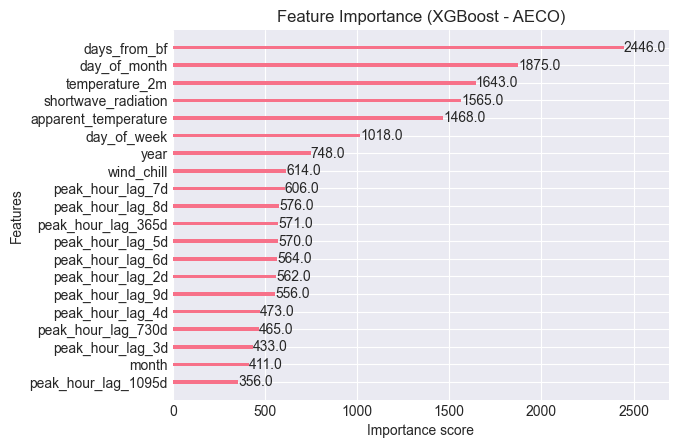

In [44]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

model = xgb_models["AECO"]  # 예시 area

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=20)  # top 20
plt.title("Feature Importance (XGBoost - AECO)")
plt.show()


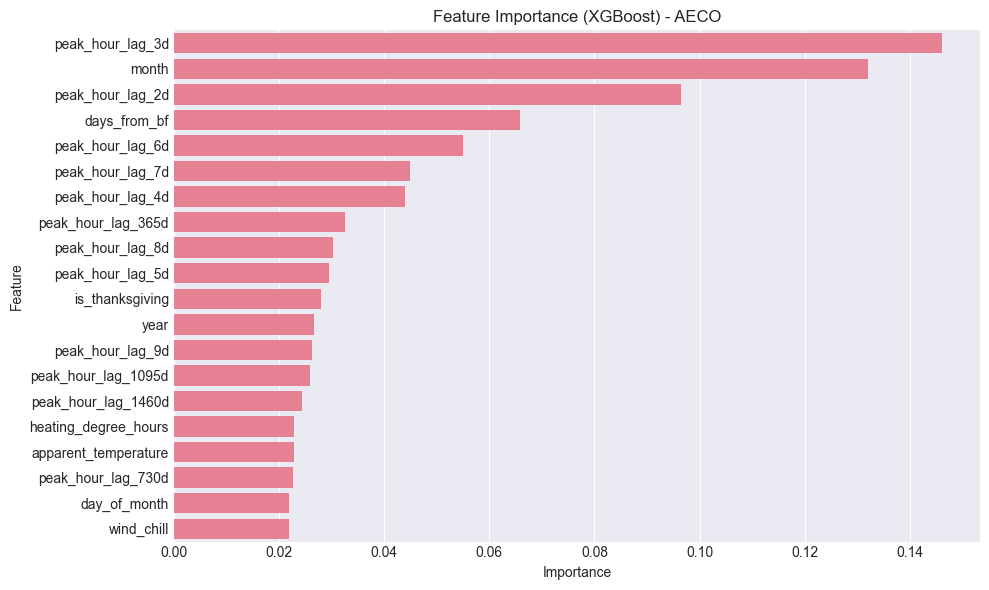

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

area = "AECO"

df_area = feature_importance_df[feature_importance_df['load_area'] == area] \
              .sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(y="feature", x="importance", data=df_area.head(20))  # Top 20
plt.title(f"Feature Importance (XGBoost) - {area}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


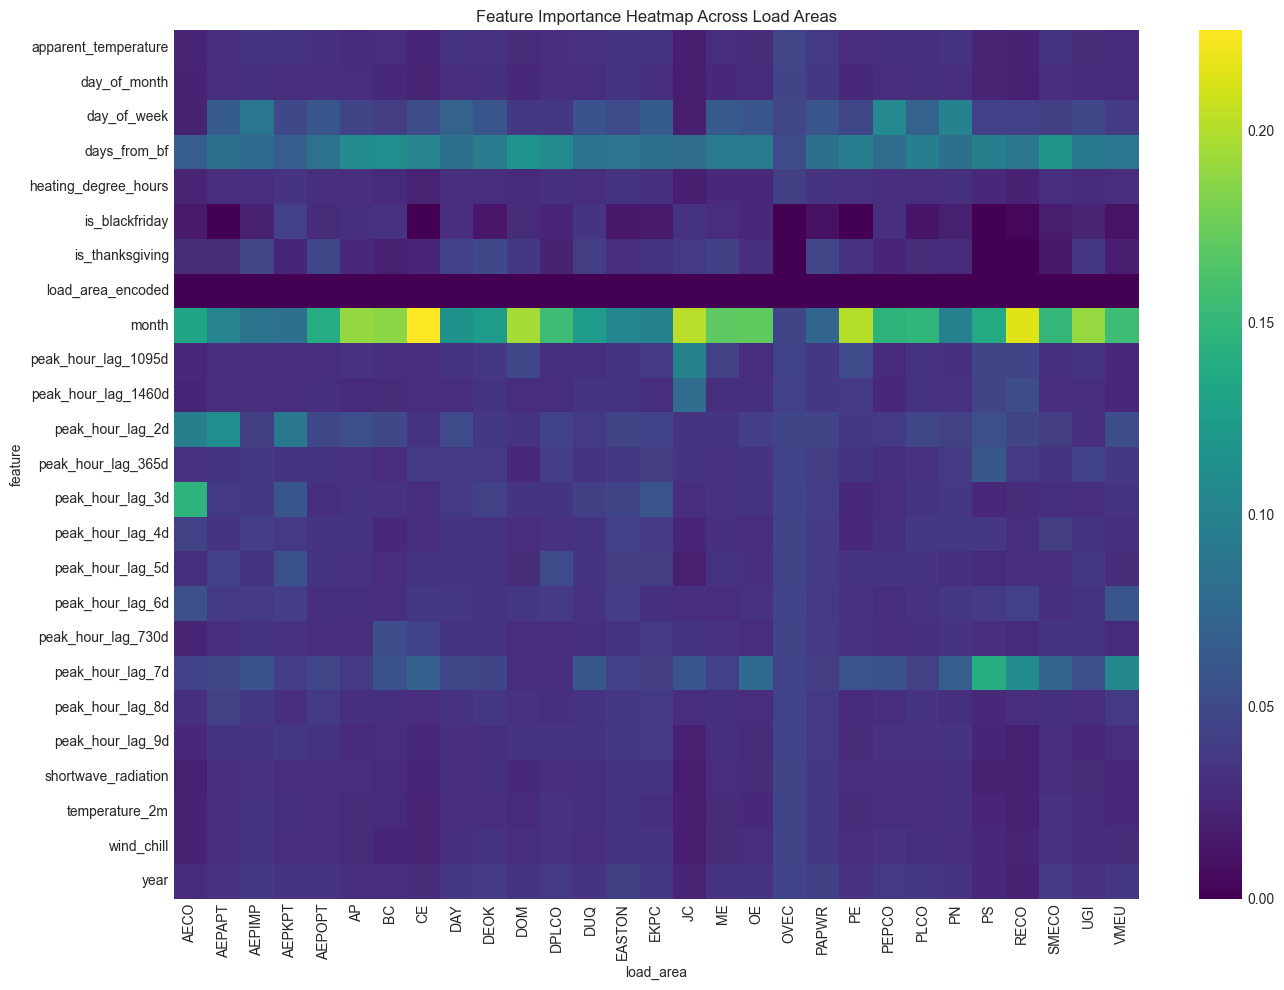

In [46]:
pivot_df = feature_importance_df.pivot(
    index="feature", 
    columns="load_area", 
    values="importance_norm"
)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df, cmap="viridis")
plt.title("Feature Importance Heatmap Across Load Areas")
plt.tight_layout()
plt.show()